In [4]:
%load_ext autoreload
%autoreload 1

In [5]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy.stats import spearmanr

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from collections import Counter

import Geometry

from IPython.display import display, clear_output

In [41]:
from __future__ import print_function
import warnings
warnings.filterwarnings('ignore') # make the notebook nicer


# import os
# os.environ['QT_QPA_PLATFORM']='offscreen'

import nglview as nv
import pytraj as pt

print("nglview version = {}".format(nv.__version__))
print("pytraj version = {}".format(pt.__version__))

from Bio.PDB import PDBParser, Select, PDBIO, Polypeptide
from Bio.SeqUtils import seq1

nglview version = 3.1.1
pytraj version = 2.0.6


In [42]:
import IPython

In [43]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [46]:
from protein_utils import read_pfam_table_pandas

In [122]:
from adk_drawer import get_guiding_structures, ss_to_domains, draw_adk, compute_domains, nw

ss_cmap = {'H':'red', 'E':'blue', 'L':'gray'}
domain_cmap = {'core':'red', 'lid':'blue', 'nmp':'green', 'none':'gray', 'ploop':'yellow'}
nglview_list = lambda cmap, residue_ss: [[cmap[r], str(i)] for i, r in enumerate(residue_ss)]

In [123]:
from __future__ import print_function
import warnings
warnings.filterwarnings('ignore') # make the notebook nicer


# import os
# os.environ['QT_QPA_PLATFORM']='offscreen'

import nglview as nv
import pytraj as pt

print("nglview version = {}".format(nv.__version__))
print("pytraj version = {}".format(pt.__version__))

from Bio.PDB import PDBParser, Select, PDBIO, Polypeptide
from Bio.SeqUtils import seq1

nglview version = 3.1.1
pytraj version = 2.0.6


# Load unfiltered data

In [11]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_save.tsv', sep='\t')
metrics_df.head()

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,sc_internal_hbonds,total_cc_contacts,yhh_planarity,%S,%L,%H,length,avg_cc_contacts_per_res,temp,mean_temp
0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,21.0,...,21.0,576.0,0.040,0.122995,0.267380,0.609626,187.0,3.080214,37.0,37.0
1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,30.0,...,34.0,599.0,0.034,0.167442,0.348837,0.483721,215.0,2.786047,30.0,30.0
2,119.5,11.289720,49.538232,GB_GCA_000242235.1,-419.604,1.327,10.981,2.842,128.0,22.0,...,29.0,664.0,0.146,0.163551,0.322430,0.514019,214.0,3.102804,37.0,37.0
3,105.5,11.276190,50.018080,GB_GCA_000283575.1,-452.738,1.390,10.905,2.771,129.0,20.0,...,23.0,589.0,0.012,0.171429,0.328571,0.500000,210.0,2.804762,30.0,30.0
4,91.0,11.359116,51.483049,GB_GCA_001054945.1,-431.800,1.243,10.768,2.669,117.0,20.0,...,31.0,532.0,0.053,0.127072,0.270718,0.602210,181.0,2.939227,37.0,37.0


In [12]:
secondary_structure = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_ss_save.tsv', sep='\t', index_col=0)['secondary_structure']
secondary_structure.head()

genome_id
GB_GCA_000016765.1    LEEEEELLLLLLHHHHHHHHHHHHLLEEEEHHHHHHHHHHLLLHHH...
GB_GCA_000242235.1    LLEEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHHLLH...
GB_GCA_000283575.1    LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000376885.1    LEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLHHH...
GB_GCA_000411155.1    LLLEEEEELLLLLLHHHHHHHHHHHHLLLEEEHHHHHHHHHHLLLH...
Name: secondary_structure, dtype: object

# Developing quality control filters

In [13]:
metrics_df.head()

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,sc_internal_hbonds,total_cc_contacts,yhh_planarity,%S,%L,%H,length,avg_cc_contacts_per_res,temp,mean_temp
0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,21.0,...,21.0,576.0,0.040,0.122995,0.267380,0.609626,187.0,3.080214,37.0,37.0
1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,30.0,...,34.0,599.0,0.034,0.167442,0.348837,0.483721,215.0,2.786047,30.0,30.0
2,119.5,11.289720,49.538232,GB_GCA_000242235.1,-419.604,1.327,10.981,2.842,128.0,22.0,...,29.0,664.0,0.146,0.163551,0.322430,0.514019,214.0,3.102804,37.0,37.0
3,105.5,11.276190,50.018080,GB_GCA_000283575.1,-452.738,1.390,10.905,2.771,129.0,20.0,...,23.0,589.0,0.012,0.171429,0.328571,0.500000,210.0,2.804762,30.0,30.0
4,91.0,11.359116,51.483049,GB_GCA_001054945.1,-431.800,1.243,10.768,2.669,117.0,20.0,...,31.0,532.0,0.053,0.127072,0.270718,0.602210,181.0,2.939227,37.0,37.0


# 1. Sequence length
Sequences between 175 and 230 bp

In [9]:
# get lengths from rosetta
lengths = secondary_structure.apply(lambda x: len(x))
# add column
metrics_df['seq_length'] = metrics_df['uid'].apply(lambda x: lengths.loc[x])

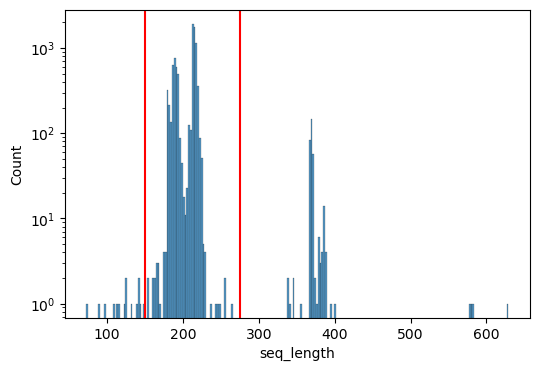

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(metrics_df['seq_length'])
ax.axvline(275, color='red')
ax.axvline(150, color='red')
ax.set_yscale('log')
# ax.set_xlim(165, 240)

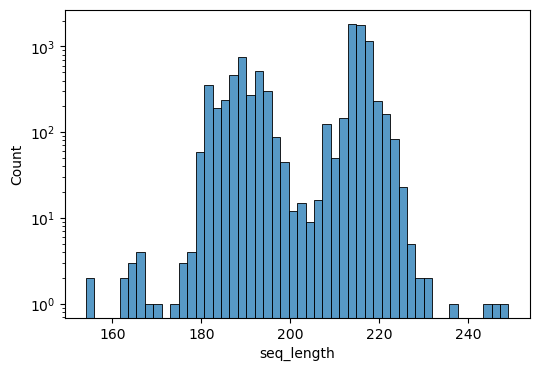

In [93]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(metrics_df.query('seq_length < 250 and seq_length > 150')['seq_length'], bins=50)
# ax.axvline(275, color='red')
# ax.axvline(150, color='red')
ax.set_yscale('log')
# ax.set_xlim(165, 240)

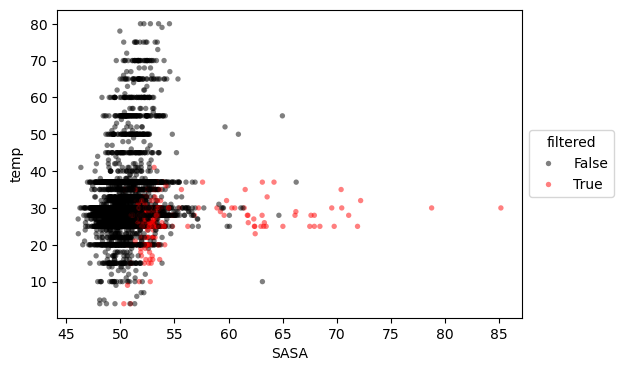

In [11]:
# plot of what is removed
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=metrics_df, x='SASA', y='temp', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=0.5, 
                hue=~metrics_df.uid.isin(metrics_df.query('seq_length < 250 & seq_length > 175').uid), 
                palette=['k', 'r']
               )
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

# 2. Bitscore
bitscore > 110

In [12]:
%%time
# get bitscores
adks = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/adks/*.faa')
count = 1
bitscores = pd.Series()
for a in adks:
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)
    with open(a, 'r') as handle:
        lines = handle.readlines()
    if len(lines) > 0:
        bitscores.loc[a.split('/')[-1].split('_adk')[0]] = float(lines[0].split('|bitscore=')[-1].strip())
    count += 1

CPU times: user 8.27 s, sys: 594 ms, total: 8.87 s
Wall time: 11.7 s


In [13]:
metrics_df['bitscore'] = metrics_df['uid'].apply(lambda x: bitscores.loc[x])

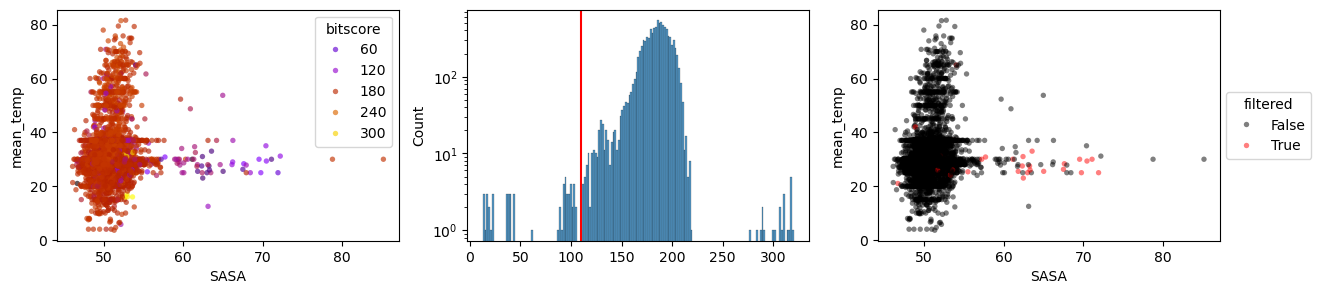

In [87]:
fig = plt.figure(figsize=(15, 3))
ax = fig.add_subplot(1,3,1)
sns.scatterplot(data=metrics_df, x='SASA', y='mean_temp', 
                hue='bitscore',
                palette='gnuplot',
                linewidth=0, alpha=0.65, s=15)

ax = fig.add_subplot(1,3,2)
sns.histplot(bitscores, ax=ax)
ax.axvline(110, color='r')
ax.set_yscale('log')

ax = fig.add_subplot(1,3,3)
sns.scatterplot(data=metrics_df.sort_values('bitscore'), x='SASA', y='mean_temp', 
                linewidth=0, alpha=0.5, s=15,
                hue=~metrics_df.uid.isin(metrics_df.query('bitscore > 110').uid),
                palette=['k', 'r']
               )
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

# 3. Domain length
P > 2  
L > 5

In [16]:
%%time
n_resid = []
count = 1
for acc in metrics_df['uid']:
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)
    # print(acc)
    sl = compute_domains(secondary_structure.loc[acc], verbose=False, mm=2)
    n_resid.append(pd.Series(data=sl).value_counts().rename(acc))
    count += 1
    # print()

CPU times: user 2min 57s, sys: 239 ms, total: 2min 58s
Wall time: 2min 57s


In [17]:
n_resid_domains = pd.concat(n_resid, axis=1).T

In [18]:
n_resid_domains.head()

,C,L,N,P
GB_GCA_000376885.1,90.0,48.0,42.0,6.0
GB_GCA_000016765.1,116.0,49.0,43.0,6.0
GB_GCA_000242235.1,117.0,48.0,42.0,6.0
GB_GCA_000283575.1,112.0,48.0,43.0,6.0
GB_GCA_001054945.1,88.0,44.0,42.0,6.0


In [20]:
metrics_df = pd.merge(metrics_df, n_resid_domains, left_on='uid', right_index=True)

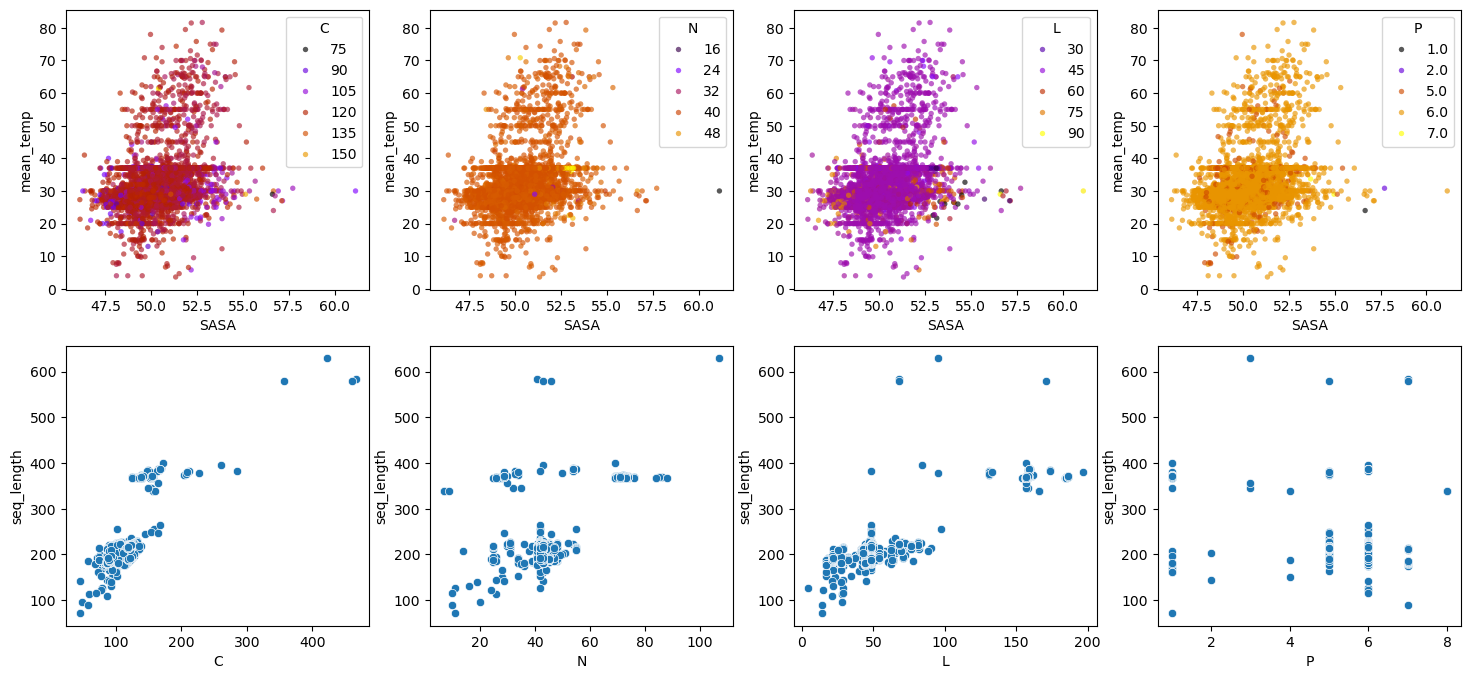

In [88]:
fig = plt.figure(figsize=(18, 8))
for i, domain in enumerate(['C', 'N', 'L', 'P']):
    ax = fig.add_subplot(2, 4, i+1)
    sns.scatterplot(data=metrics_df.query('seq_length < 250 & seq_length > 200'),
                    x='SASA',
                    y='mean_temp',
                    hue=domain,
                    palette='gnuplot',
                    linewidth=0, alpha=0.65, s=15)
    
for i, domain in enumerate(['C', 'N', 'L', 'P']):
    ax = fig.add_subplot(2, 4, i+5)
    sns.scatterplot(data=metrics_df, x=domain, y='seq_length')
    # ax.set_yscale('log')
    # ax.set_ylim(150, 250)

In [38]:
metrics_df.query('seq_length < 250 & seq_length > 200').sort_values('L', ascending=False)

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,length,avg_cc_contacts_per_res,temp,mean_temp,seq_length,bitscore,C,L,N,P
4135,107.5,10.981308,56.603682,RS_GCF_003367395.1,-465.350,1.299,10.495,2.447,147.0,20.0,...,214.0,2.747664,29.0,29.000000,214,190.6,75.0,90.0,42.0,6.0
7041,105.0,10.830918,61.136284,RS_GCF_014333445.1,-437.364,1.280,10.362,2.419,127.0,29.0,...,207.0,3.067633,30.0,30.000000,207,17.0,98.0,88.0,14.0,6.0
4110,116.0,11.520000,47.687607,RS_GCF_003352835.1,-541.123,1.471,11.453,3.037,142.0,37.0,...,225.0,3.084444,29.0,28.166667,225,13.1,104.0,83.0,31.0,6.0
358,107.0,11.427230,54.041105,RS_GCF_000173615.1,-567.376,1.376,10.944,2.827,139.0,38.0,...,213.0,3.295775,70.0,64.986146,213,19.4,93.0,82.0,31.0,6.0
685,110.0,11.557604,50.737955,RS_GCF_000300195.1,-507.485,1.369,10.954,2.895,138.0,40.0,...,217.0,3.308756,37.0,37.000000,217,22.4,98.0,81.0,31.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,104.0,11.283582,52.167101,RS_GCF_007748195.1,-430.201,1.348,10.582,2.644,134.0,24.0,...,201.0,3.213930,28.0,28.000000,201,91.9,127.0,22.0,46.0,5.0
3420,101.5,11.306931,51.167235,RS_GCF_002831565.1,-419.559,1.277,10.792,2.639,132.0,31.0,...,202.0,3.044554,25.0,25.000000,202,169.6,123.0,22.0,50.0,6.0
870,102.0,11.251232,52.932780,RS_GCF_000374065.1,-426.641,1.276,10.764,2.607,133.0,30.0,...,203.0,3.088670,20.0,22.500000,203,171.1,123.0,22.0,51.0,6.0
871,102.0,11.330049,53.143780,RS_GCF_000374085.1,-405.922,1.246,10.754,2.548,135.0,26.0,...,203.0,2.970443,20.0,21.666667,203,172.1,123.0,22.0,51.0,6.0


In [43]:
genome = 'RS_GCF_003367395.1'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'
pdb = f'{struct_path}{file}'

# load pdb
pdb = f'{struct_path}{file}'
traj = pt.load(pdb)
w = nv.show_pytraj(traj, default_representation=False)
w.add_cartoon(color='gray')


print(len(secondary_structure.loc[genome]))

# s2r, sa = ss_to_domains(ss)
c2core = {'C':'core', 'L':'lid', 'N':'nmp', 'P':'ploop'}
structure_loc = compute_domains(secondary_structure.loc[genome], verbose=True, mm=2)
sa = [c2core[i] for i in structure_loc]
colors = nglview_list(domain_cmap, sa)

scheme = nv.color._ColorScheme(colors, label='domains')

w.add_cartoon(color=scheme)

display(w)

214
LELHLEHLHLHLHLELHLELHLHLELHLHL
30
LELHLEHLHLH---LHLELH----LELHLHLELH--LHL
LELHLEHLHLHLLELHLELHLELELELELELELHLELHL
CCPCCCNNNNNCCCCCCCCLLLLLLLLLLLLLLCCCCCC
CCPCCCNNNNNCCCCCCCCLLLLLLLLLLLLLLCCCCCC


NGLWidget()

In [14]:
genome = 'RS_GCF_003367395.1'
file = f'{genome}_closed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/test_structures/'

draw_adk(f'{struct_path}{file}', color_ss=ss_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

# 4. Extra structure length

In [44]:
%%time
# Removing structures with long loops

max_loop_lengths = pd.Series(dtype='float')

for g in metrics_df['uid']:
    # print(g)
    s2r, sa = ss_to_domains(secondary_structure.loc[g])
    loop_lengths = [len(range(int(k.split('-')[0]), int(k.split('-')[1]))) for k, i in s2r.items()]
    max_loop_lengths.loc[g] = np.max(loop_lengths)

CPU times: user 11.1 s, sys: 76.8 ms, total: 11.2 s
Wall time: 11.1 s


In [45]:
metrics_df['max_structure_length'] = metrics_df['uid'].apply(lambda x: max_loop_lengths.loc[x])

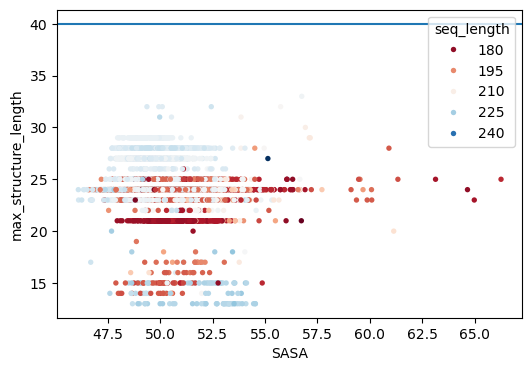

In [56]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=metrics_df.query('seq_length < 250 & seq_length > 175').set_index('uid'), x='SASA', y='max_structure_length', edgecolor=None, color='black', s=15,
                linewidth=0, alpha=1, hue='seq_length', palette='RdBu'
               )
ax.axhline(40)
# lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

In [57]:
metrics_df.query('seq_length < 250 & seq_length > 175 & max_structure_length < 18')

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,avg_cc_contacts_per_res,temp,mean_temp,seq_length,bitscore,C,L,N,P,max_structure_length
34,114.0,11.102222,53.585391,GB_GCA_016919005.1,-477.475,1.382,10.938,2.827,136.0,35.0,...,3.226667,28.0,28.000000,225,144.5,104.0,72.0,42.0,6.0,13
48,95.5,11.484211,50.018967,RS_GCF_000007905.1,-435.688,1.263,10.905,2.688,126.0,41.0,...,3.289474,37.0,41.500000,190,121.4,108.0,32.0,44.0,5.0,15
61,112.0,11.094170,52.923306,RS_GCF_000010665.1,-511.091,1.439,10.857,2.570,139.0,34.0,...,3.578475,30.0,30.000000,223,133.0,103.0,68.0,45.0,6.0,15
146,112.5,11.375000,49.399961,RS_GCF_000020365.1,-499.058,1.482,11.071,2.797,139.0,37.0,...,3.616071,26.0,26.000000,224,141.7,106.0,68.0,43.0,6.0,13
158,96.5,11.552083,49.576420,RS_GCF_000021725.1,-485.903,1.260,10.917,2.715,127.0,36.0,...,3.135417,42.0,38.702230,192,134.9,110.0,32.0,44.0,5.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9109,95.5,11.589474,49.923734,RS_GCF_900198605.1,-415.524,1.274,10.874,2.688,126.0,38.0,...,3.231579,37.0,37.000000,190,120.4,108.0,32.0,44.0,5.0,14
9137,111.0,11.357466,48.624912,RS_GCF_900217235.1,-459.460,1.471,10.973,2.752,135.0,34.0,...,3.656109,30.0,28.333333,221,127.1,102.0,68.0,44.0,6.0,14
9191,94.5,11.638298,51.111235,RS_GCF_900476215.1,-425.994,1.223,10.947,2.695,121.0,34.0,...,3.420213,37.0,37.000000,188,115.8,106.0,32.0,44.0,5.0,15
9257,105.0,11.464115,53.772924,RS_GCF_900660615.1,-499.101,1.278,10.780,2.642,127.0,34.0,...,3.569378,37.0,37.000000,209,149.1,93.0,62.0,47.0,6.0,17


In [1]:

genome = 'GB_GCA_016919005.1'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NameError: name 'draw_adk' is not defined

# 5. Lid
\> 25 if length > 200

In [ ]:
lid_tables = glob.glob('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/PF05191/*_tblout.txt')

# list for all pfam tables
all_adk_lid_tables = []
genomes = []

# for each pfam table
WRITE_FILE = False
count = 0
for file in lid_tables:

    # counter
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)
    # read table
    try:
        genome = file.split('/')[-1].split('_tbl')[0]
        genomes.append(genome)
        df = read_pfam_table_pandas(file)
        all_adk_lid_tables.append(df.assign(genome=genome))
        
    except ValueError:
        ''
        # print(f'Table contained no records:\n{file}')

    count += 1



lids = pd.concat(all_adk_lid_tables)

lids = lids.groupby('genome').apply(lambda x: x.sort_values('full_score', ascending=False).iloc[0, :])

In [67]:
metrics_df['lid_bitscore'] = metrics_df['uid'].apply(lambda x: lids.loc[x, 'full_score'] if x in lids.index else 0)

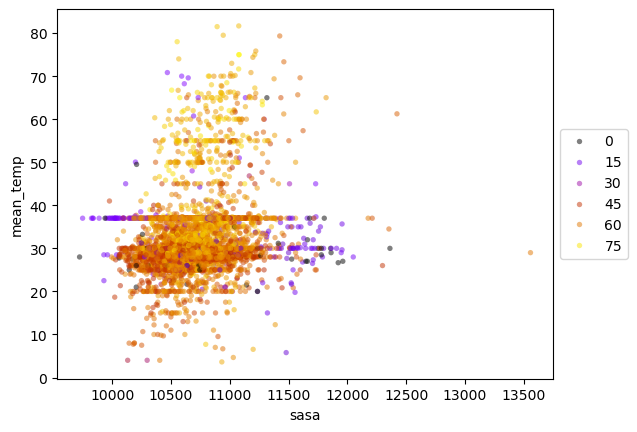

In [71]:
fig, ax = plt.subplots()
sns.scatterplot(data=metrics_df.query('seq_length < 250 & seq_length > 200'), 
                x='sasa', y='mean_temp', 
                linewidth=0, s=15, alpha=0.5, 
                hue='lid_bitscore', palette='gnuplot'
               )
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [74]:
metrics_df.query('mean_temp == 37').set_index('uid').sort_values('sasa', ascending=True)['sasa']

uid
RS_GCF_011250635.1     7718.945
RS_GCF_000980835.1     8564.290
RS_GCF_900460955.1     8619.980
RS_GCF_000428805.1     8689.080
RS_GCF_001293125.1     8693.482
                        ...    
RS_GCF_003054025.1    19129.522
RS_GCF_003259525.1    19238.973
RS_GCF_009684755.1    19533.212
RS_GCF_004340205.1    20071.095
RS_GCF_004916895.1    22655.783
Name: sasa, Length: 1225, dtype: float64

In [75]:
genome = 'RS_GCF_011250635.1'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

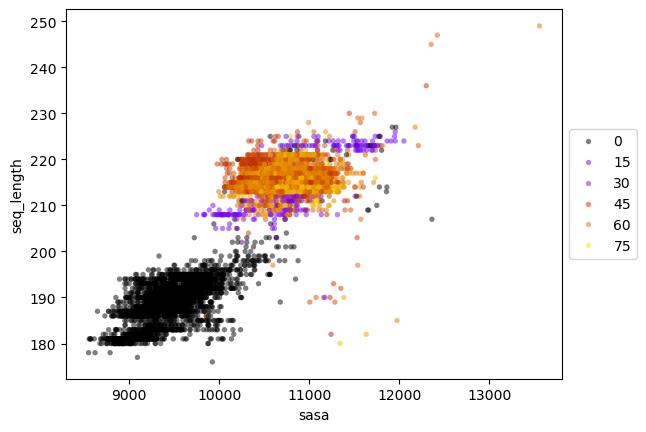

In [78]:
fig, ax = plt.subplots()
sns.scatterplot(data=metrics_df.query('seq_length < 250 & seq_length > 175'), 
                x='sasa', y='seq_length', 
                linewidth=0, s=15, alpha=0.5, 
                hue='lid_bitscore', palette='gnuplot'
               )
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

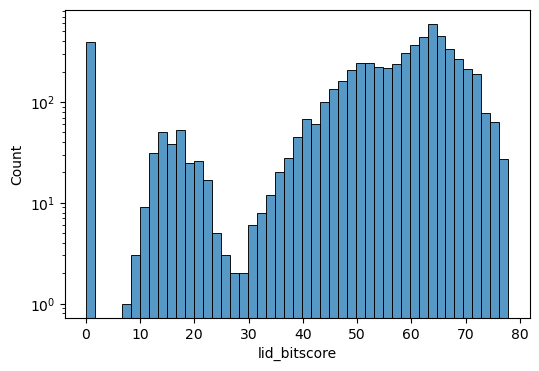

In [83]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(metrics_df.query('seq_length > 200')['lid_bitscore'])
ax.set_yscale('log')

### Final: unexpected number of helices, sheets, or loops

In [110]:
structure_counts = pd.DataFrame(index=metrics_df['uid'], columns=['E', 'L', 'H'])
count = 0
for g in metrics_df['uid']:
    if count % 100 == 0:
        display(count)
        clear_output(wait=True)
    s2r, sa = ss_to_domains(secondary_structure.loc[g])
    c = Counter()
    for k, i in s2r.items():
        if len(range(int(k.split('-')[0]), int(k.split('-')[1]))) >= 5:
            c[i[0]] += 1
    structure_counts.loc[g, :] = pd.Series(c)
    count += 1

9300

In [111]:
if any(c in metrics_df.columns for c in ['E', 'L', 'H']):
    metrics_df.drop(['E', 'L', 'H'], axis=1, inplace=True)

metrics_df = pd.merge(metrics_df, structure_counts, left_on='uid', right_index=True)

metrics_df.head(2)

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,%H,length,avg_cc_contacts_per_res,temp,seq_length,max_structure_length,mean_temp,E,L,H
0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,21.0,...,0.609626,187.0,3.080214,37.0,187,24,37.0,3,5,8
1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,30.0,...,0.483721,215.0,2.786047,30.0,215,23,30.0,3,8,8


# PCA and plots

In [96]:
filter_data = lambda df, f: df.query(' & '.join(list(set(f))))

In [169]:
filters = ['seq_length <= 230',
 'seq_length >= 175',
 'P > 2',
 'bitscore > 110',
 '`%S` > 0.11']

In [170]:
filtered = filter_data(metrics_df, filters)
filtered = filtered[((filtered['seq_length'] > 200) & (filtered['lid_bitscore'] > 25)) |  (filtered['seq_length'] < 200)]

<Axes: xlabel='SASA', ylabel='mean_temp'>

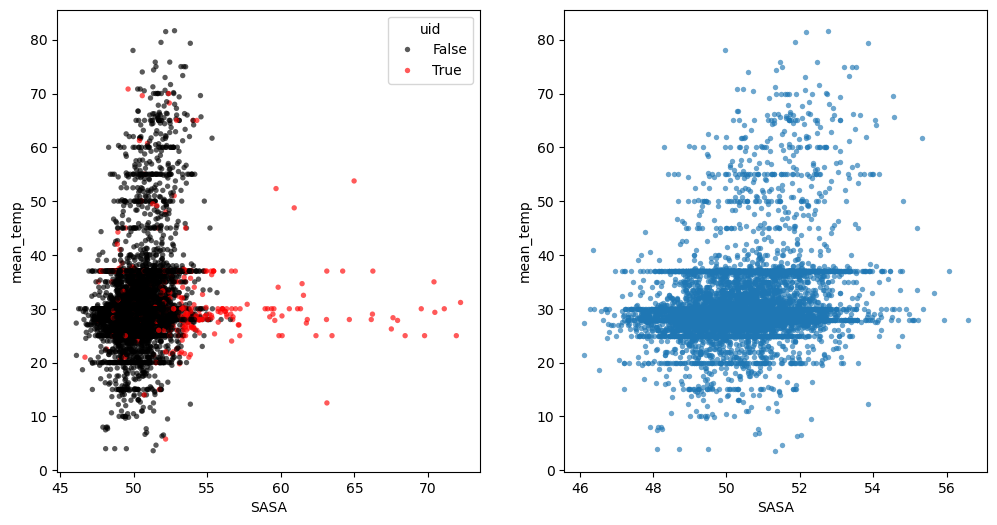

In [168]:
fig = plt.figure(figsize=(12, 6))
args = {'linewidth':0, 's':15, 'alpha':0.65}
ax = fig.add_subplot(1,2,1)
sns.scatterplot(data=metrics_df.query('seq_length < 250'), x='SASA', y='mean_temp',
               hue=~metrics_df.uid.isin(filtered.uid), palette=['k', 'r'],
               **args)

ax = fig.add_subplot(1,2,2)
sns.scatterplot(data=filtered, x='SASA', y='mean_temp',
               **args)


In [120]:
from sklearn.manifold import TSNE

In [140]:
X = filtered[[col for col in filtered.columns if filtered[col].dtype != 'O']].T.values

CPU times: user 3min 39s, sys: 323 ms, total: 3min 39s
Wall time: 24.1 s


<Axes: xlabel='0', ylabel='1'>

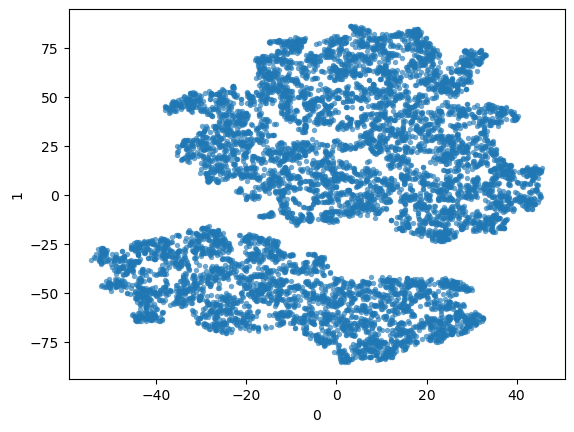

In [133]:
%%time
X_embedded = TSNE(n_components=2, learning_rate='auto',
              init='random', perplexity=50).fit_transform(X)

sns.scatterplot(data=pd.DataFrame(X_embedded), x=0, y=1,
               **args)

In [135]:
from sklearn.decomposition import PCA

In [143]:
pca = PCA(n_components=5)
pca.fit(X)

PCA(n_components=5)

In [147]:
pca_df = pd.DataFrame(pca.components_).T
pca_df.columns = [f'PC{i}' for i in range(1,6)]
pca_df.index = filtered.uid.values

<Axes: xlabel='PC1', ylabel='PC2'>

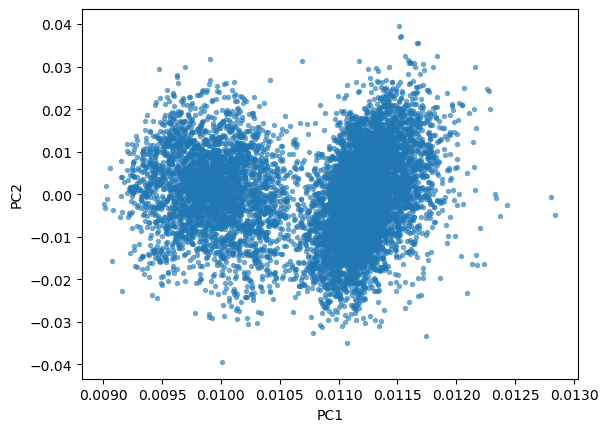

In [149]:
sns.scatterplot(data=pca_df, x='PC1', y='PC2', **args)

<Axes: xlabel='PC2', ylabel='PC3'>

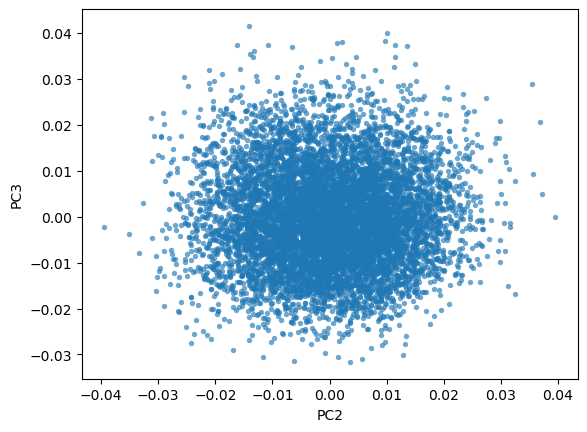

In [150]:
sns.scatterplot(data=pca_df, x='PC2', y='PC3', **args)

In [138]:
# %%time
# X_embedded = TSNE(n_components=2, learning_rate='auto',
#               init='random', perplexity=50).fit_transform(metrics_df[[col for col in filtered.columns if filtered[col].dtype != 'O']].values)

# sns.scatterplot(data=pd.DataFrame(X_embedded), x=0, y=1,
#                **args)

# Exploring bad signals more

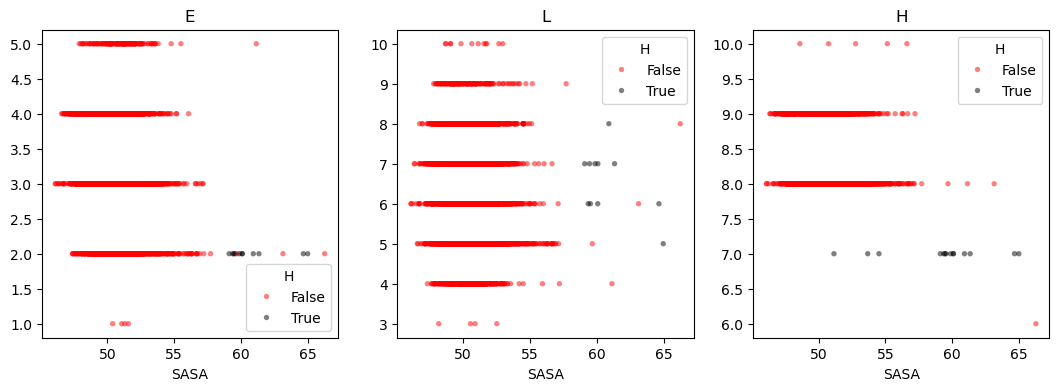

In [112]:
fig = plt.figure(figsize=(13,4))
filtered = filter_data(metrics_df, filters)
for i, metric  in enumerate(['S', 'L', 'H']):
    ax = fig.add_subplot(1,3,i+1)
    sns.scatterplot(data=filtered, x='SASA', y=metric, edgecolor=None, color='black', s=15,
                    linewidth=0, alpha=0.5, hue=filtered['H'].isin([7]), palette=['red', 'k']
                   )
    ax.set_title(metric)
    ax.set_ylabel('')
# lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

In [152]:
metrics_df.columns

Index(['Position', 'Contacts at 4.5 Å', 'SASA', 'uid', 'total_score',
       'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary',
       'bb_internal_hbonds', 'bbsc_internal_hbonds', 'cav_vol', 'dslf_fa13',
       'fa_atr', 'fa_dun', 'fa_elec', 'fa_intra_rep', 'fa_intra_sol_xover4',
       'fa_rep', 'fa_sol', 'hbond_bb_sc', 'hbond_lr_bb', 'hbond_sc',
       'hbond_sr_bb', 'internal_hbonds', 'lk_ball_wtd', 'nonpolar_sasa',
       'omega', 'p_aa_pp', 'packstat', 'polar_sasa', 'pro_close',
       'rama_prepro', 'ref', 'sasa', 'sc_internal_hbonds', 'total_cc_contacts',
       'yhh_planarity', '%S', '%L', '%H', 'length', 'avg_cc_contacts_per_res',
       'temp', 'mean_temp', 'seq_length', 'bitscore', 'C', 'L', 'N', 'P',
       'max_structure_length', 'lid_bitscore'],
      dtype='object')

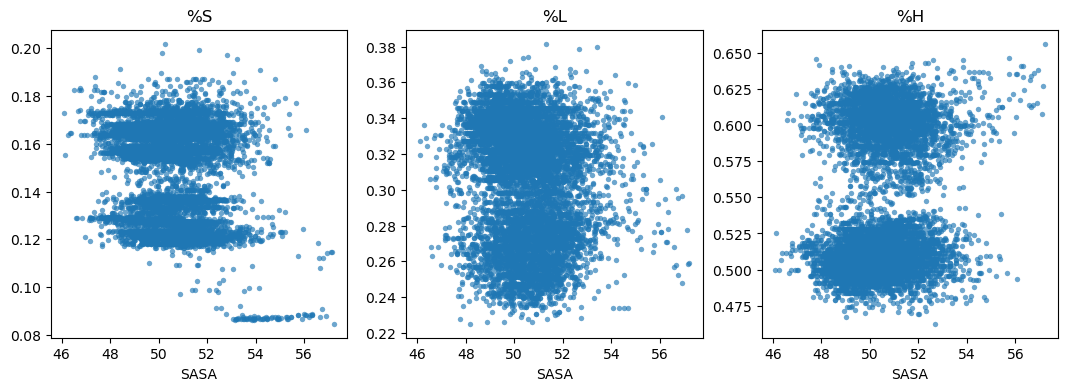

In [155]:
fig = plt.figure(figsize=(13,4))
filtered = filter_data(metrics_df, filters)
for i, metric  in enumerate(['%S', '%L', '%H']):
    ax = fig.add_subplot(1,3,i+1)
    sns.scatterplot(data=filtered, x='SASA', y=metric, 
                    **args, palette=['red', 'k']
                   )
    ax.set_title(metric)
    ax.set_ylabel('')
# lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='filtered')

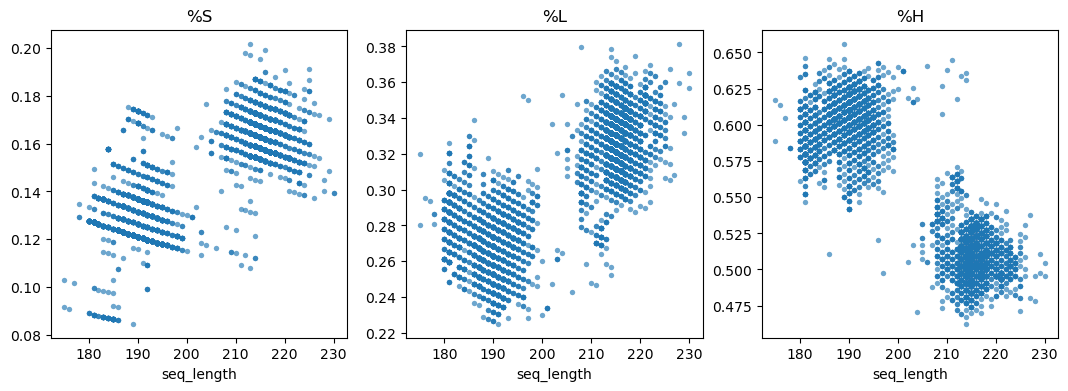

In [160]:
fig = plt.figure(figsize=(13,4))
filtered = filter_data(metrics_df, filters)
for i, metric  in enumerate(['%S', '%L', '%H']):
    ax = fig.add_subplot(1,3,i+1)
    sns.scatterplot(data=filtered, x='seq_length', y=metric, 
                    **args, palette=['red', 'k']
                   )
    ax.set_title(metric)
    ax.set_ylabel('')

In [158]:
filter_data(metrics_df, filters).query('`%S` < 0.1').sort_values('SASA', ascending=False).head()

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,temp,mean_temp,seq_length,bitscore,C,L,N,P,max_structure_length,lid_bitscore
3851,109.0,10.656085,57.209079,RS_GCF_003173715.1,-363.795,1.275,10.280,2.422,122.0,14.0,...,25.0,25.0,189,177.2,87.0,54.0,43.0,4.0,24,0.0
3447,91.5,11.076923,56.909017,RS_GCF_002860355.1,-423.054,1.308,10.418,2.511,119.0,24.0,...,37.0,37.0,182,171.9,84.0,48.0,42.0,7.0,24,0.0
3772,88.5,10.920455,56.733953,RS_GCF_003096675.1,-377.167,1.352,10.500,2.547,113.0,21.0,...,28.0,28.0,176,190.1,82.0,44.0,42.0,7.0,21,0.0
3387,92.0,11.125683,56.648221,RS_GCF_002802905.1,-419.006,1.306,10.421,2.555,118.0,22.0,...,37.0,37.0,183,170.1,85.0,48.0,42.0,7.0,24,0.0
3217,91.0,11.082873,56.335713,RS_GCF_002259795.1,-394.068,1.320,10.547,2.603,115.0,20.0,...,29.0,28.5,181,160.3,83.0,48.0,42.0,7.0,24,0.0


In [161]:

genome = 'RS_GCF_003173715.1'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

# Filtering and Saving

In [171]:
metrics_df.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_full.tsv', sep='\t')
filtered.to_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv', sep='\t')

# Generating high-quality alignment for downstream analyses

In [305]:
from Bio import SeqIO

In [306]:
aln_stats = []
with open('./../data/high_qual_alignments/full_adk_reps_initial.afa', 'r') as handle:
    
    for record in SeqIO.parse(handle, "fasta"):
        # Get the sequence string and convert it to uppercase
        seq = str(record.seq).upper()
        total_length = len(seq)
        
        # Count gap characters (typically '-' in MAFFT alignments)
        gap_count = seq.count('-')
        
        # Count non-gap characters (residues)
        residue_count = total_length - gap_count
        
        # Calculate percentages
        gap_percentage = (gap_count / total_length * 100) if total_length > 0 else 0
        residue_percentage = 100 - gap_percentage
        
        aln_stats.append({
            # BioPython's record.id handles the sequence header up to the first space
            'sequence_id': record.id, 
            'sligned_length': total_length,
            'residue_count': residue_count,
            'gap_count': gap_count,
            'gap_percentage': gap_percentage,
            'residue_percentage': residue_percentage
        })

In [307]:
plotdf = pd.DataFrame(aln_stats)

In [308]:
plotdf['hue'] = plotdf['sequence_id'].str.contains('\|adk\|').map({True:'bacterial', False:'reference'})

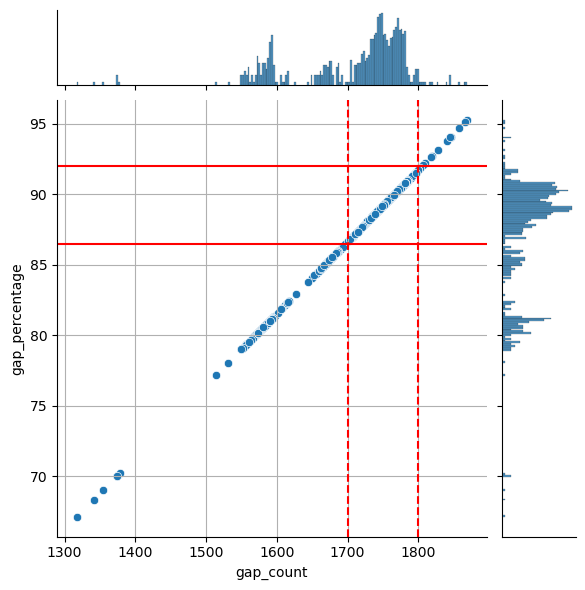

In [312]:
# fig = plt.figure(figsize=(6,4))
# sns.histplot(data=plotdf, x='gap_percentage', hue='hue')
g = sns.jointplot(data=plotdf, y='gap_percentage', x='gap_count')
sns.despine()
g.ax_joint.axvline(1700, color='r', linestyle='--')
g.ax_joint.axvline(1800, color='r', linestyle='--')

g.ax_joint.axhline(86.5, color='r')
g.ax_joint.axhline(92, color='r')

g.ax_marg_x.set_yscale('log')
g.ax_marg_y.set_xscale('log')
g.ax_joint.grid(True,axis='both')

# ax.set_yscale('log')
# ax.axvline(1790, color='r')

## Round 1: filtering on gap count and bitscore

### Notes
An initial analysis of the alignment on the filtered data with gap percentage > 86.5 and < 92 showed the alignment was not good: over 800 units long. Further investigation revealed a few long and low-bitscore sequences were responsible for a large majority of these gaps.

In [313]:
with open('./../data/high_qual_alignments/full_adk_reps.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

# filtering on gaps
filtered_ids = plotdf[(plotdf['gap_percentage'] >= 86.5) & (plotdf['gap_percentage'] < 92)]['sequence_id'].values
filtered_records = [r for r in records if r.id in filtered_ids]
print(f'Number of filtered records: {len(filtered_records)}')

def get_bitscore(_str):
    if not 'bitscore=' in _str:
        return np.nan
    else:
        return float(_str.split('bitscore=')[-1])

filtered_records = [r for r in filtered_records if get_bitscore(r.id) > 100]
print(f'Number of filtered records: {len(filtered_records)}')

with open('./../data/high_qual_alignments/full_adk_reps.filtered.faa', 'w') as handle:
    SeqIO.write(filtered_records, handle, format='fasta')

Number of filtered records: 7157
Number of filtered records: 6910


In [314]:
plotdf[plotdf['gap_count'] < 1800].sequence_id.values

array(['CP000388.1_2963|GB_GCA_000014225.1|adk|temp=23.0|bitscore=198.5',
       'CP000699.1_1354|GB_GCA_000016765.1|adk|temp=30.0|bitscore=175.3',
       'JH590862.1_220|GB_GCA_000242235.1|adk|temp=37.0|bitscore=192.2',
       ..., 'Q9WUR9|reviewed|Adenylate', 'Q9ZCS6|reviewed|Adenylate',
       'Q9ZUU1|reviewed|Adenylate'], dtype=object)

In [315]:
# check lengths of filtered reps
with open('./../data/high_qual_alignments/full_adk_reps.filtered.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

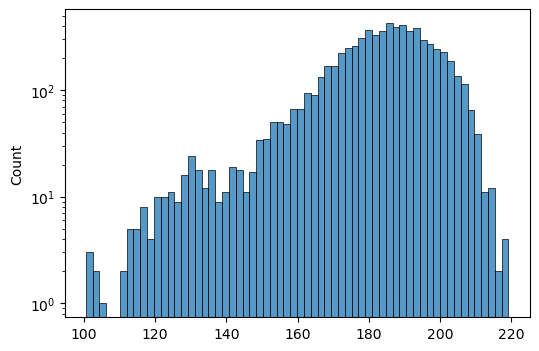

In [316]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot([get_bitscore(r.id) for r in records])
ax.set_yscale('log')

## Notes
Here: perform second alignment of filtered sequences

## Round 2: sequences with rare columns

In [317]:
def find_alignment_bloaters(alignment_path, threshold=0.01):
    """
    Identifies sequences responsible for increasing alignment length.
    Threshold: Columns with residues in fewer than this % of sequences are 
    considered 'rare insertion' columns.
    """
    records = list(SeqIO.parse(alignment_path, "fasta"))
    num_seqs = len(records)
    num_cols = len(records[0].seq)
    
    print(f"Analyzing {num_seqs} sequences with {num_cols} columns...")

    # Convert alignment to a numpy character array for speed
    # We treat '-' and '.' as gaps, everything else as a residue
    data = np.array([list(str(rec.seq)) for rec in records])
    is_residue = (data != '-') & (data != '.')
    
    # Calculate occupancy per column
    col_occupancy = np.sum(is_residue, axis=0) / num_seqs
    
    # Identify "rare" columns (those below the threshold)
    rare_col_indices = np.where(col_occupancy < threshold)[0]
    print(f"Found {len(rare_col_indices)} columns with < {threshold*100}% occupancy.")

    # For each sequence, count how many of these rare columns it occupies
    bloat_contributions = []
    for i, record in enumerate(records):
        # Count residues in the rare columns for this specific sequence
        bloat_count = np.sum(is_residue[i, rare_col_indices])
        bloat_contributions.append((record.id, bloat_count, len(record.seq) - str(record.seq).count('-')))

    # Sort by bloat contribution descending
    bloat_contributions.sort(key=lambda x: x[1], reverse=True)

    print("\nTop 10 Sequences Increasing Alignment Length:")
    print(f"{'Sequence ID':<30} | {'Bloat Columns':<15} | {'Actual Length'}")
    print("-" * 60)
    for name, bloat, length in bloat_contributions[:20]:
        print(f"{name[:30]:<30} | {bloat:<15} | {length}")

    return bloat_contributions


In [276]:
bloat_data = find_alignment_bloaters('./../data/high_qual_alignments/full_adk_reps.filtered.afa', 0.001)

Analyzing 6643 sequences with 373 columns...
Found 54 columns with < 0.1% occupancy.

Top 10 Sequences Increasing Alignment Length:
Sequence ID                    | Bloat Columns   | Actual Length
------------------------------------------------------------
NZ_JAFBBO010000001.1_1216|RS_G | 9               | 205
NZ_SOZH01000005.1_338|RS_GCF_0 | 8               | 203
NZ_JNIF01000003.1_1698|RS_GCF_ | 7               | 226
NZ_BAFU01000020.1_13|RS_GCF_00 | 6               | 188
NZ_BAGE01000018.1_210|RS_GCF_0 | 6               | 188
NZ_CP036319.1_3780|RS_GCF_0077 | 6               | 201
NC_019892.1_6290|RS_GCF_000242 | 4               | 224
NZ_SJKB01000012.1_54|RS_GCF_00 | 4               | 199
NZ_AUAC01000003.1_400|RS_GCF_0 | 3               | 210
NZ_RYZH01000033.1_59|RS_GCF_00 | 3               | 223
NZ_SLWV01000010.1_65|RS_GCF_00 | 3               | 227
NZ_WEZF01000016.1_8|RS_GCF_009 | 3               | 223
KE150266.1_745|GB_GCA_00041115 | 2               | 203
NC_000908.2_190|RS_GCF_0000

<Axes: xlabel='n_gappy', ylabel='length'>

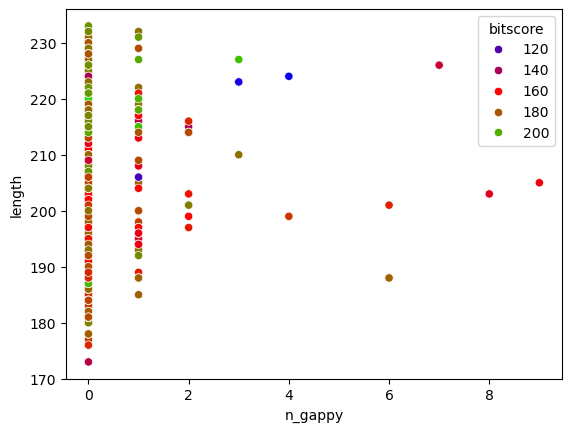

In [216]:
# generate plot of problematic sequences

bloat_df = pd.DataFrame(bloat_data, columns=['id', 'n_gappy', 'length'])
bloat_df['bitscore'] = bloat_df['id'].apply(lambda x: x.split('bitscore=')[-1].replace('bitscore=', ''))

bloat_df = bloat_df[~bloat_df.bitscore.str.contains('\|')]

bloat_df.bitscore = bloat_df.bitscore.astype(float)

sns.scatterplot(data=bloat_df, x='n_gappy', y='length', hue='bitscore', palette='brg')

In [209]:
gappy_seqs = list(bloat_df[bloat_df.n_gappy > 0]['id'].unique())

In [214]:
with open('./../data/high_qual_alignments/full_adk_reps.filtered.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]
    
print(f'Number of records: {len(records)}')
filtered_records = [r for r in records if not r.id in gappy_seqs]
print(f'Number of filtered records: {len(filtered_records)}')

with open('./../data/high_qual_alignments/full_adk_reps.filtered.faa', 'w') as handle:
    SeqIO.write(filtered_records, handle, format='fasta')

Number of records: 6848
Number of filtered records: 6643


## Examining trimmed alignment

In [278]:
with open('./../data/high_qual_alignments/full_adk_reps.filtered.trimmed.afa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

## Generating filtered sequences to insert into backbone sequence

In [285]:
## generating filtered adk fasta
filtered = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t', compression='gzip')

In [290]:
with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/20240122_all_adks.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

print(len(records))

unique_uids = filtered['uid'].unique()
adk_filtered_records = [r for r in records if r.id.split('|')[1] in unique_uids]
print(len(adk_filtered_records))
with open('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/20240122_all_adks_filtered.faa', 'w') as handle:
    SeqIO.write(adk_filtered_records, handle, format='fasta')
    

9351
8532


In [297]:
# generating a second fasta of sequences absent from the backbone alignment
with open('./../data/high_qual_alignments/full_adk_reps.filtered.trimmed.afa', 'r') as handle:
    highqual_trimmed_records = [r for r in SeqIO.parse(handle, format='fasta')]

trimmed_ids = set([r.id for r in highqual_trimmed_records])

print(f'Number of highqual trimmed records: {len(highqual_trimmed_records)}')
print(f'Number of filtered records (based on structure): {len(adk_filtered_records)}')
non_trimmed_records = [r for r in adk_filtered_records if r.id in trimmed_ids]
print(f'Number of filtered records present in highqual file: {len(non_trimmed_records)}')
non_trimmed_records = [r for r in adk_filtered_records if not r.id in trimmed_ids]
print(f'Number of filtered records absent from highqual file: {len(non_trimmed_records)}')

Number of highqual trimmed records: 6643
Number of filtered records (based on structure): 8532
Number of filtered records present in highqual file: 6344
Number of filtered records absent from highqual file: 2188


In [298]:
with open('./../data/high_qual_alignments/extra_adk_seqs.faa', 'w') as handle:
    SeqIO.write(non_trimmed_records, handle, format='fasta')
    

### Notes
Here's the deal: There's a backbone alignment (`full_adk_reps.filtered.trimmed.afa`) which has 6,643 sequences, dereplicated and filtered from `20240122_all_adks.faa`. When provided sequences to MSA transformer for prediction or training, they are inserted into this alignment. However, when this file was generated it lost some sequences (2,188) from `data/metric_tables/20240327_metrics_df_filtered.tsv.gz`, which is the "canonical" list of ADKs I'm confident have a reasonable structure. The file `high_qual_alignments/extra_adk_seqs.faa` contains these 2,188 sequences, which are inserted into the backbone alignment before training of the finalized transformer.

In [304]:
from matplotlib_venn import venn2

ModuleNotFoundError: No module named 'matplotlib_venn'

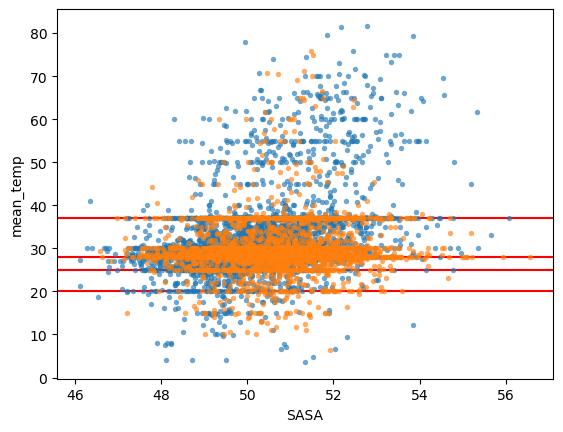

In [189]:
fig, ax = plt.subplots()
for qstr in ['seq_length > 200', 'seq_length < 200']:
    sns.scatterplot(data=filtered.query(qstr), x='SASA', y='mean_temp', **args)
for i in [20, 25, 28, 37]:
    ax.axhline(i, color='r', zorder=0)

In [190]:
filtered.query('mean_temp == 37 & seq_length > 200').sort_values('SASA', ascending=False)

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,temp,mean_temp,seq_length,bitscore,C,L,N,P,max_structure_length,lid_bitscore
5046,113.0,11.255605,56.068751,RS_GCF_004359375.1,-427.351,1.341,10.614,2.635,134.0,30.0,...,37.0,37.0,223,185.4,125.0,49.0,42.0,6.0,25,53.1
8719,108.0,11.153488,54.769990,RS_GCF_900128415.1,-461.850,1.344,10.767,2.622,130.0,33.0,...,37.0,37.0,215,171.5,117.0,48.0,43.0,6.0,24,60.9
790,109.0,11.317972,54.463340,RS_GCF_000340375.1,-497.489,1.332,10.788,2.720,139.0,31.0,...,37.0,37.0,217,170.0,114.0,48.0,48.0,6.0,24,65.9
1452,114.0,11.462555,54.462971,RS_GCF_000526235.1,-508.164,1.273,10.639,2.623,144.0,31.0,...,37.0,37.0,227,179.9,129.0,48.0,43.0,6.0,24,60.7
52,105.0,11.253589,54.297539,RS_GCF_000008185.1,-448.803,1.278,10.761,2.687,128.0,26.0,...,37.0,37.0,209,185.2,112.0,48.0,42.0,6.0,23,56.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3399,107.5,11.345794,48.135517,RS_GCF_002807665.1,-484.600,1.336,10.776,2.782,130.0,29.0,...,37.0,37.0,214,197.0,118.0,48.0,42.0,5.0,27,63.9
9098,114.5,11.309091,48.056102,RS_GCF_900188335.1,-437.801,1.373,11.018,2.756,131.0,28.0,...,37.0,37.0,220,189.4,121.0,49.0,43.0,6.0,24,52.0
5351,108.0,11.162791,47.723221,RS_GCF_005887635.2,-462.717,1.363,10.823,2.747,129.0,28.0,...,37.0,37.0,215,184.5,116.0,49.0,43.0,6.0,23,50.5
1335,117.5,11.236364,47.242150,RS_GCF_000473145.1,-458.269,1.427,11.036,2.845,133.0,29.0,...,37.0,37.0,220,187.3,95.0,76.0,42.0,6.0,24,45.4


In [191]:
genome = 'RS_GCF_004359375.1'
file = f'{genome}_A_processed.pdb'
struct_path = '/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/'

draw_adk(f'{struct_path}{file}', color_domains=domain_cmap, ss=secondary_structure.loc[genome])

NGLWidget()

In [195]:
f'{struct_path}{file}'

'/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/processed_structures/RS_GCF_004359375.1_A_processed.pdb'

In [192]:
gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t')

In [194]:
gtdb_md.set_index('accession').loc['RS_GCF_004359375.1', 'gtdb_taxonomy']

'd__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Acetilactobacillus;s__Acetilactobacillus jinshanensis'